In [1]:
import pandas as pd

In [2]:
data = {
    ('Math','Score'):[90,85],
    ('Math','Grade'):['A','B'],
    ('Science','Score'):[88,92],
    ('Science','Grade'):['B','A']
}

index = pd.Index(['Student1','Student2'])
df = pd.DataFrame(data, index=index)
df.columns = pd.MultiIndex.from_tuples(df.columns)
print(df)
print(df['Math']['Score'])

          Math       Science      
         Score Grade   Score Grade
Student1    90     A      88     B
Student2    85     B      92     A
Student1    90
Student2    85
Name: Score, dtype: int64


In [3]:
df.loc['Student1',('Math','Grade')]

'A'

In [4]:
df = pd.DataFrame({
    'Department':['Sales','Sales','IT','IT','HR','HR'],
    'Employee':['Alice','Bob','Charlie','David','Eve','Frank'],
    'Salary':[50000,55000,60000,62000,48000,47000],
    'Bonus':['5000','6000','7000','7200','3000','2800']
})

In [5]:
print(df)

  Department Employee  Salary Bonus
0      Sales    Alice   50000  5000
1      Sales      Bob   55000  6000
2         IT  Charlie   60000  7000
3         IT    David   62000  7200
4         HR      Eve   48000  3000
5         HR    Frank   47000  2800


In [6]:
grouped = df.groupby('Department').agg({
    'Salary':['mean','max'],
    'Bonus':['sum','min']
})

print(grouped)

             Salary            Bonus      
               mean    max       sum   min
Department                                
HR          47500.0  48000  30002800  2800
IT          61000.0  62000  70007200  7000
Sales       52500.0  55000  50006000  5000


In [7]:
grouped.columns = ['_'.join(col) for col in grouped.columns]
grouped.reset_index(inplace=True)
print(grouped)

  Department  Salary_mean  Salary_max Bonus_sum Bonus_min
0         HR      47500.0       48000  30002800      2800
1         IT      61000.0       62000  70007200      7000
2      Sales      52500.0       55000  50006000      5000


In [8]:
# using transform to bradcast the group mean

df['AvgDeptSalary'] = df.groupby('Department')['Salary'].transform('mean')

def range_func(x):
    return x.max() - x.min()

df['SalaryRange'] = df.groupby('Department')['Salary'].transform(range_func)
print(df)

  Department Employee  Salary Bonus  AvgDeptSalary  SalaryRange
0      Sales    Alice   50000  5000        52500.0         5000
1      Sales      Bob   55000  6000        52500.0         5000
2         IT  Charlie   60000  7000        61000.0         2000
3         IT    David   62000  7200        61000.0         2000
4         HR      Eve   48000  3000        47500.0         1000
5         HR    Frank   47000  2800        47500.0         1000


In [9]:
df1 = pd.DataFrame({
    'Day':pd.date_range(start='2023-01-01',periods=7,freq='D'),
    'Sale':[100,120,130,90,150,170,160]
})



In [10]:
df1.set_index('Day',inplace=True)
print(df1)

            Sale
Day             
2023-01-01   100
2023-01-02   120
2023-01-03   130
2023-01-04    90
2023-01-05   150
2023-01-06   170
2023-01-07   160


In [11]:
df1['Rolling_Mean'] = df1['Sale'].rolling(window=3).mean()
print(df1)

            Sale  Rolling_Mean
Day                           
2023-01-01   100           NaN
2023-01-02   120           NaN
2023-01-03   130    116.666667
2023-01-04    90    113.333333
2023-01-05   150    123.333333
2023-01-06   170    136.666667
2023-01-07   160    160.000000


In [12]:
df1['Expanding_Mean'] = df1['Sale'].expanding().mean()
print(df1)

            Sale  Rolling_Mean  Expanding_Mean
Day                                           
2023-01-01   100           NaN      100.000000
2023-01-02   120           NaN      110.000000
2023-01-03   130    116.666667      116.666667
2023-01-04    90    113.333333      110.000000
2023-01-05   150    123.333333      118.000000
2023-01-06   170    136.666667      126.666667
2023-01-07   160    160.000000      131.428571


In [13]:
df1['Rolling_Std'] = df1['Sale'].rolling(3).std()

In [14]:
df1

,Sale,Rolling_Mean,Expanding_Mean,Rolling_Std
Day,,,,
2023-01-01,100,NaN,100.000000,NaN
2023-01-02,120,NaN,110.000000,NaN
2023-01-03,130,116.666667,116.666667,15.275252
2023-01-04,90,113.333333,110.000000,20.816660
2023-01-05,150,123.333333,118.000000,30.550505
2023-01-06,170,136.666667,126.666667,41.633320
2023-01-07,160,160.000000,131.428571,10.000000


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df2 = sns.load_dataset('tips')
print(df2.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


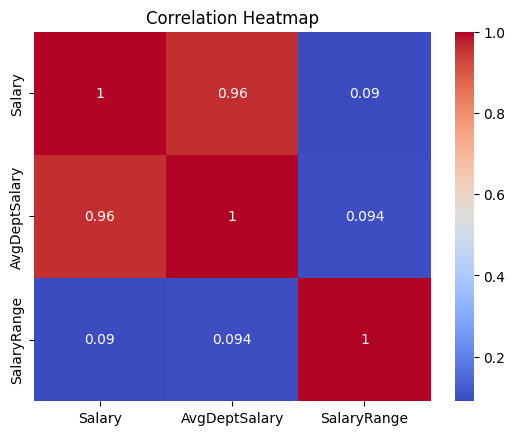

In [16]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

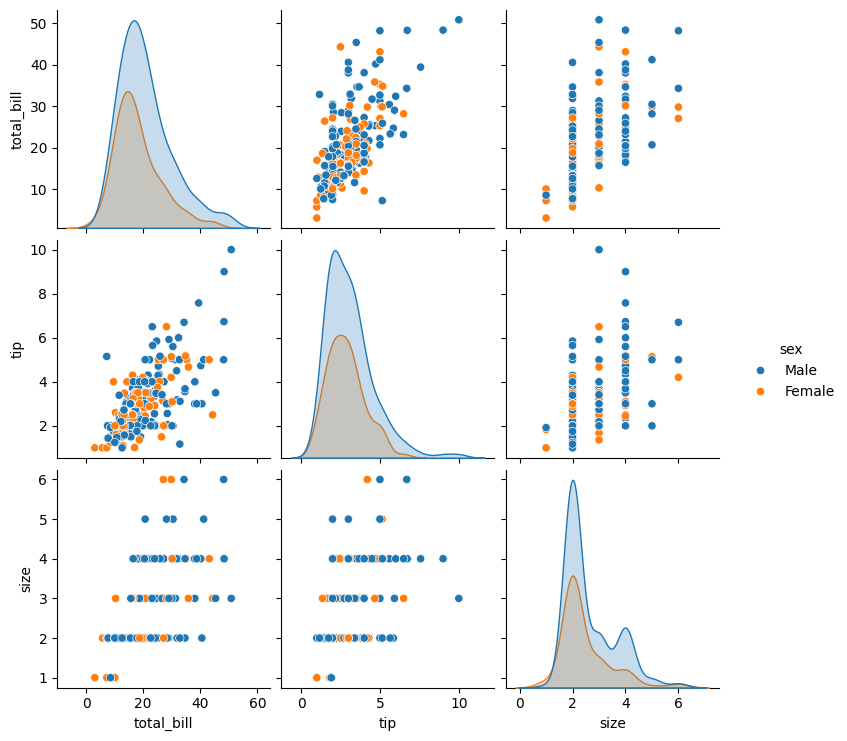

In [18]:
sns.pairplot(df2,hue='sex')
plt.show()

C:\Users\francis\AppData\Local\Temp\ipykernel_15760\1119972229.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df2.groupby('day')['tip'].mean().reset_index()


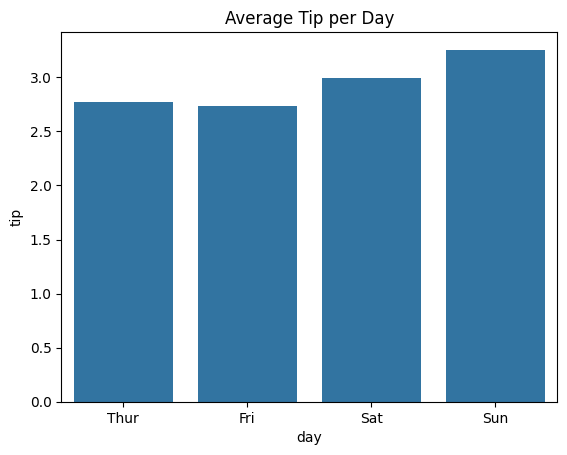

In [19]:
grouped = df2.groupby('day')['tip'].mean().reset_index()

sns.barplot(data=grouped,x='day',y='tip')
plt.title('Average Tip per Day')
plt.show()

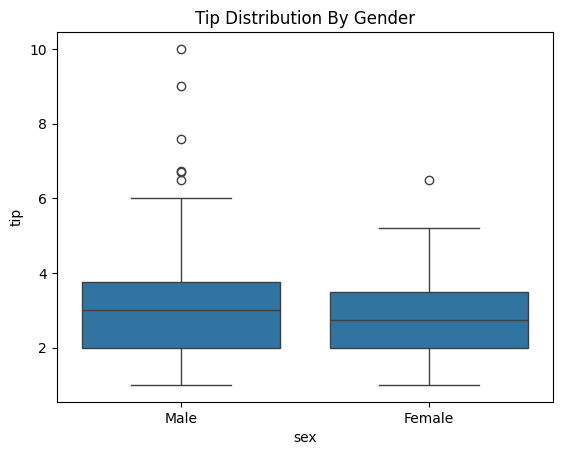

In [20]:
sns.boxplot(data=df2,x='sex',y='tip')
plt.title('Tip Distribution By Gender')
plt.show()

In [21]:
penguins = sns.load_dataset('penguins')

In [22]:
#drop rows with missing values:
penguins = penguins.dropna()

In [23]:
print(penguins.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  


In [24]:
print(penguins.info())

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB
None


In [ ]:
#check missing values
print(penguins.isnull().sum())

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [26]:
print(penguins.dtypes)

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


In [27]:
# average body mass per species
print(penguins.groupby('species')['body_mass_g'].mean())

species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5092.436975
Name: body_mass_g, dtype: float64


In [28]:
# Average bill lenght by species and sex
print(penguins.groupby(['species','sex'])['bill_length_mm'].mean())

species    sex   
Adelie     Female    37.257534
           Male      40.390411
Chinstrap  Female    46.573529
           Male      51.094118
Gentoo     Female    45.563793
           Male      49.473770
Name: bill_length_mm, dtype: float64


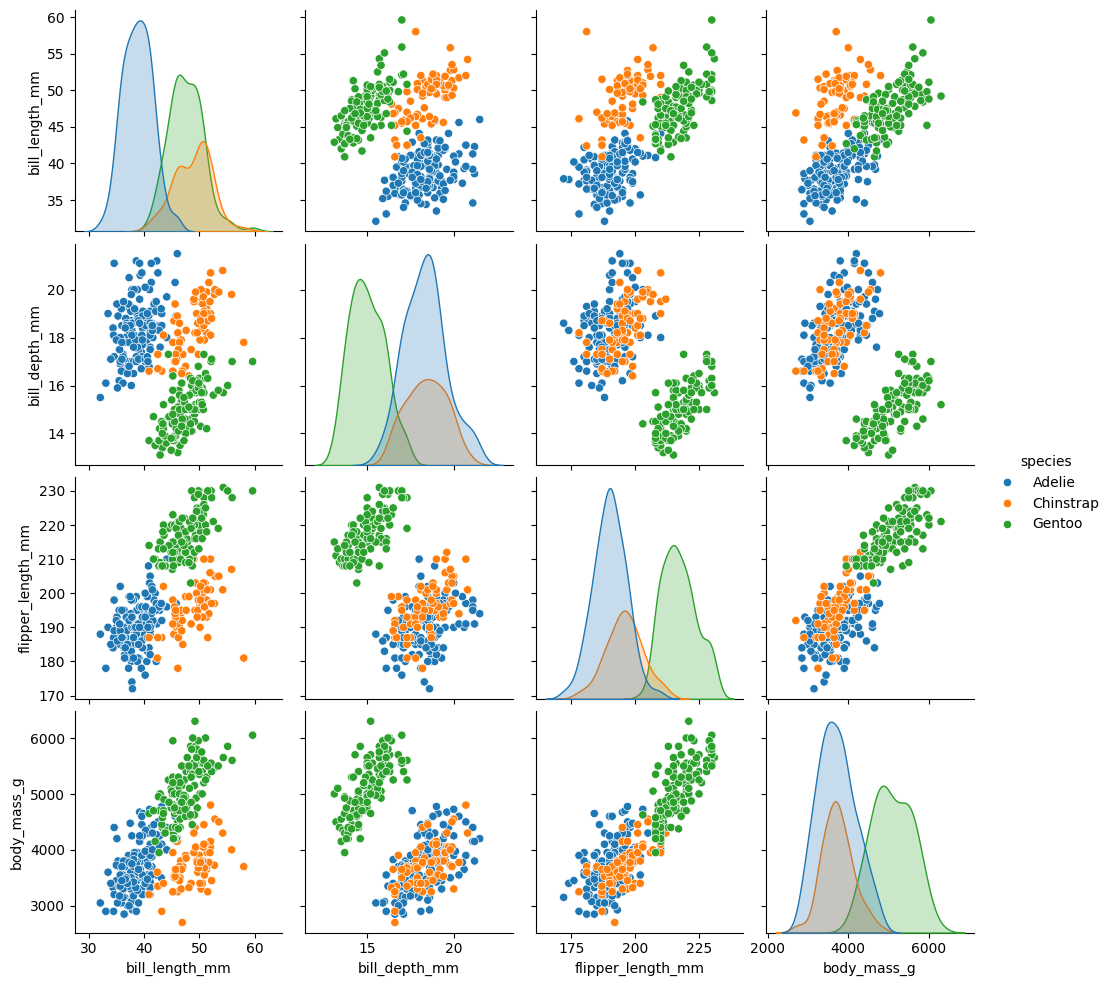

In [29]:
sns.pairplot(penguins,hue='species')

<Axes: >

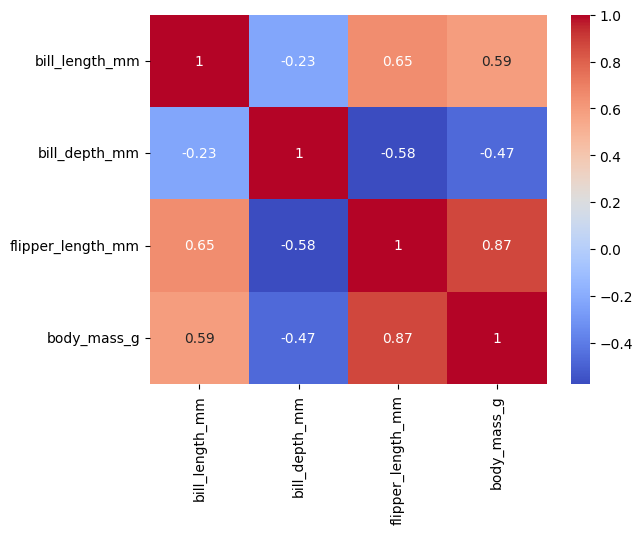

In [30]:
corr = penguins.select_dtypes('number').corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')

<Axes: xlabel='species', ylabel='flipper_length_mm'>

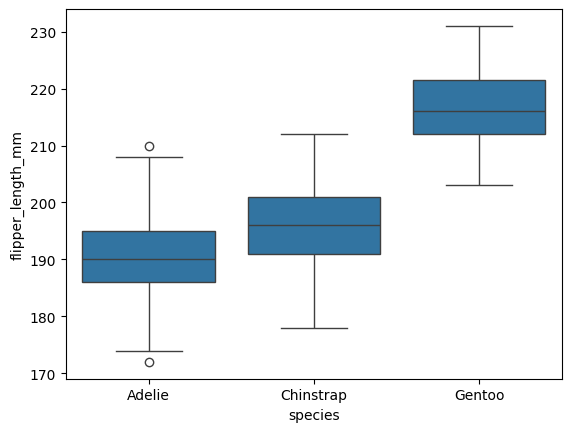

In [32]:
#7. Boxplot of Flipper Length by Species

sns.boxplot(data=penguins,x='species',y='flipper_length_mm')

<Axes: xlabel='body_mass_g', ylabel='Count'>

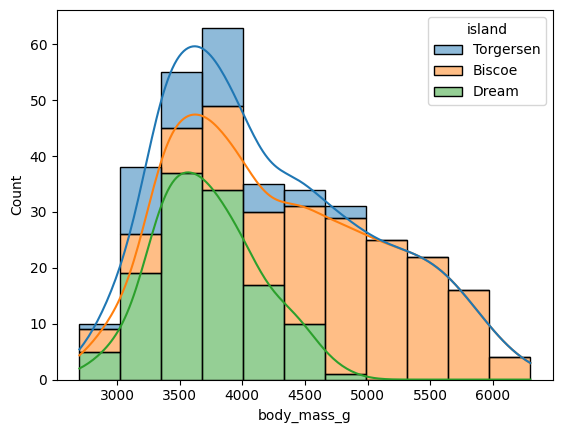

In [33]:
sns.histplot(data=penguins,x='body_mass_g',hue='island',multiple='stack',kde=True)

<Axes: xlabel='species', ylabel='body_mass_g'>

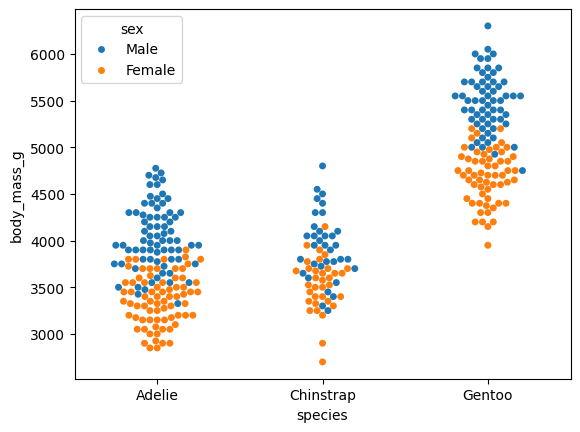

In [34]:
sns.swarmplot(data=penguins,x='species',y='body_mass_g',hue='sex')

<Axes: xlabel='species', ylabel='body_mass_g'>

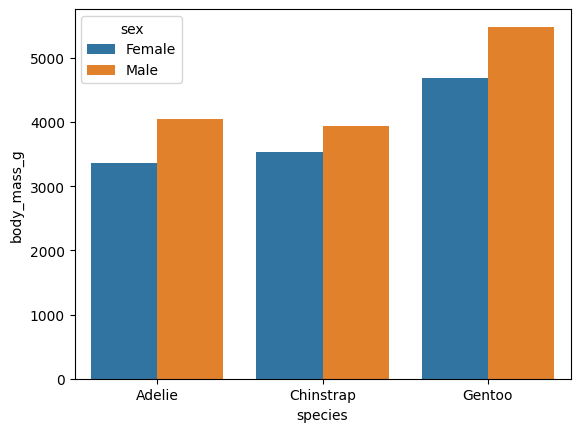

In [36]:
grouped = penguins.groupby(['species','sex'])['body_mass_g'].mean().reset_index()

sns.barplot(data=grouped,x='species',y='body_mass_g',hue='sex')

In [37]:
penguins['bill_area'] = penguins['bill_length_mm'] * penguins['bill_depth_mm']

In [38]:
print(penguins['bill_area'])

0      731.17
1      687.30
2      725.40
4      708.31
5      809.58
        ...  
338    646.64
340    669.24
341    791.28
342    668.96
343    803.39
Name: bill_area, Length: 333, dtype: float64


In [39]:
pivot = penguins.pivot_table(values='body_mass_g',index='species',columns='sex',aggfunc='mean')

In [40]:
print(pivot)

sex             Female         Male
species                            
Adelie     3368.835616  4043.493151
Chinstrap  3527.205882  3938.970588
Gentoo     4679.741379  5484.836066


<Axes: title={'center': 'AVG BODY MASS (g) by Species and Sex'}, xlabel='species'>

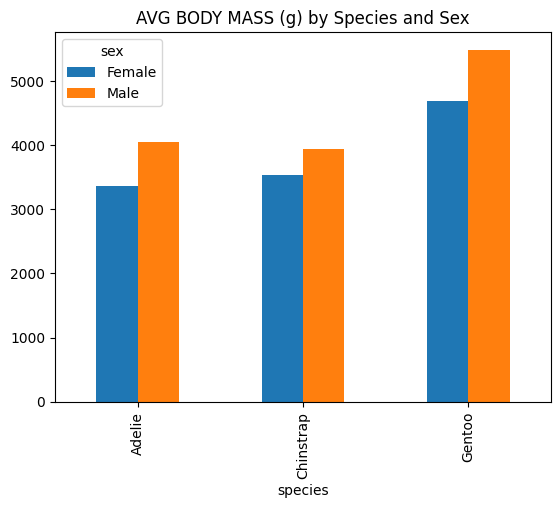

In [41]:
pivot.plot(kind='bar',title='AVG BODY MASS (g) by Species and Sex')

In [42]:
iris = sns.load_dataset('iris')
print(iris.head())
print(iris.info())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [43]:
print(iris.describe())

print(iris.groupby('species').mean())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026
